### **Problem 7.1**
Solve the linear system $Ax = b$ for $x$ where
$$ A = \begin{pmatrix}
-1 & 2 & 3\\
4 & -5 & 6\\
7 & 8 & -9
\end{pmatrix}
$$
$$ b = (12.9,-5.1,10.7)^T $$

which can also be wrtiten as

$$\begin{pmatrix}
-1 & 2 & 3\\
4 & -5 & 6\\
7 & 8 & -9
\end{pmatrix} 
\begin{pmatrix}
x_1 \\
x_2 \\
x_3 
\end{pmatrix} =
\begin{pmatrix}
12.9 \\
-5.1 \\
10.7 
\end{pmatrix}$$

In [14]:
import numpy as np

def GaussElim(A,b):
    """create a Gaussian elimination matrix for an NxN system
    Args:
        A: N by N array
        b: array of length N
    Returns:
        augmented matrix ready for back substitution
    """
    #create augmented matrix
    [Nrow, Ncol] = A.shape
    assert Nrow == Ncol
    N = Nrow
    assert b.size == N
    aug_matrix = np.zeros((N,N+1))
    aug_matrix[0:N,0:N] = A
    aug_matrix[:,N] = b
    #augmented matrix is created
    for column in range(0,N):
        for row in range(column+1,N):
            mod_row = aug_matrix[row,:]
            mod_row -= (mod_row[column]/aug_matrix[column,column]*
                        aug_matrix[column,:])
            aug_matrix[row] = mod_row
    return aug_matrix

def BackSub(aug_matrix,x):
    """back substitute a N by N system after Gaussian elimination
    Args:
        aug_matrix: augmented matrix with zeros below the diagonal
        x: length N vector to hold solution
    Returns:
        nothing
    Side Effect:
        x now contains solution
    """
    N = x.size
    [Nrow,Ncol] = aug_matrix.shape
    assert Nrow+1 == Ncol
    assert N == Nrow
    #start at the end
    for row in range(N-1,-1,-1):
        RHS = aug_matrix[row,N]
        for column in range(row+1,N):
            RHS -= x[column]*aug_matrix[row,column]
            # Pause here to illustrate the importance of proper indention...
        x[row] = RHS/aug_matrix[row,row]
    return



A = np.matrix([(-1,2,3),(4,-5,6),(7,8,-9)])
b = np.array([12.9,-5.1,10.7])
aug = GaussElim(A,b)
print(aug)
print(" ")

x = np.zeros(3)
BackSub(aug,x)
print("The solution is ", x)

[[  -1.     2.     3.    12.9]
 [   0.     3.    18.    46.5]
 [   0.     0.  -120.  -240. ]]
 
The solution is  [0.1 3.5 2. ]


### **Problem 7.2**
Consider the n by n matrix defined by

$$
A=
\begin{pmatrix}
1 & 1/2 & 1/3 & ... & 1/n\\
1/2 & 1/3 & 1/4 & ... & 1/(n+1)\\
... & & & &\\
1/n & 1/(n+1) & 1/(n+2) & ... & 1/(2n-1)
\end{pmatrix}$$
and the vector
$$ b = (1,-1,1,-1,...)^T $$
Write a function to generate $A$ and $b$ as a function of $n$. Use Gaussian elimination to
solve the system $Ax = b$ for $n = 2, 4, 8, 16$. What do you notice about your answers? Are
the answers that you get from Gaussian elimination correct?

In [15]:
import numpy as np

def ABcreator(A,b,n):
    for i in range(n):
        for j in range(n):
            A[i,j] = 1/(j+i+1)

    for i in range(n):
        if i % 2 == 0:
            b[i] = 1
        else:
            b[i] = -1
    return

nlist = [2,4,8,16] # N values to test

for k in nlist:
    A = np.zeros((k,k))
    b = np.zeros(k)
    
    ABcreator(A,b,k)

    aug = GaussElim(A,b)
    x = np.zeros(k)
    BackSub(aug,x)
    print("The solution for n =",k,"is \n",x)
    print("The residual (errors) are",np.dot(A,x)-b)
    print(" ")


# The answers start to get really, really big. The errors also get high with large n values. 
# I dont really see anything indicating that they are incorrect other than the large error, though

The solution for n = 2 is 
 [ 10. -18.]
The residual (errors) are [0. 0.]
 
The solution for n = 4 is 
 [  516. -5700. 13620. -8820.]
The residual (errors) are [0.00000000e+00 0.00000000e+00 4.54747351e-13 0.00000000e+00]
 
The solution for n = 8 is 
 [ 8.68360019e+05 -4.63836249e+07  6.04807570e+08 -3.27135737e+09
  8.80667183e+09 -1.24630507e+10  8.87175098e+09 -2.50393574e+09]
The residual (errors) are [ 4.76837158e-07  0.00000000e+00  4.76837158e-07  0.00000000e+00
  0.00000000e+00  0.00000000e+00 -2.38418579e-07  2.38418579e-07]
 
The solution for n = 16 is 
 [-1.59124643e+10  2.43754494e+12 -9.21464089e+13  1.49764646e+15
 -1.29433071e+16  6.57573652e+16 -2.04856236e+17  3.90673159e+17
 -4.40045018e+17  3.35726795e+17 -5.32409878e+17  1.28587009e+18
 -1.86270375e+18  1.49902253e+18 -6.39096827e+17  1.13597169e+17]
The residual (errors) are [ -1. -63.  -1. -31.  31.   1.  31.   1.  -1.   1.  -1.   1. -33.   1.
  -1.   1.]
 


### **Chapter 7, Programming Project 1 - Xenon Poisoning**

$^{135}Xe$ is produced in a nuclear reactor through two mechanisms:

- The production of $^{135}Te$ from fission, which then decays to $^{135}I$ via β decay with a half-life of 19 s, which then decays to $^{135Xe}$ via β decay with a half-life of 6.6 h.
- The production of $^{135}Xe$ directly from fission.

$^{135}Xe$ is important because it has a very large capture cross-section of 2.6 × 106 barns. $^{135}Xe$ is also radioactive, and decays with a half-life of 9.1 h.

For a reactor with an average scalar flux, φ in units [neutrons/cm2/s], the equations for the production of $^{135}Xe$ are (using the abbreviation number density [nuclei/cm3] of $^{135}Xe$ → $X$, $^{135}I$ → $I$ , $^{135}Te$ → $T$),

$$\frac{d}{dt}T=γ_TΣ_fφ − λ_T T,$$
$$\frac{d}{dt}I=λ_T T − λ_I I,$$
$$\frac{d}{dt}X=λ_I I + γXΣ_fφ − (λ_X + σ_a^X φ)X,$$

If we consider the steady-state limit, i.e., $\frac{d}{dt} = 0$, we have an equation for the equilibrium concentration of all three nuclides. For a $^{235}U$ fueled reactor, the fission yields for $Te$ and $Xe$ are $γ_T = 0.061$, $γ_X = 0.003$, and the macroscopic fission cross-section is $Σ_f = 0.07136 cm^{−1}$. Compute the equilibrium concentrations of these three nuclides at power densities of 5, 50, and 100 W/cm^3, using the energy per fission of 200 MeV/fission. Also, compute the absorption rate density of neutrons in $^{135}Xe$, given by $σ_a^X φX$.

In [ ]:
import numpy as np
# if d/dt = 0, then all three equations can be set to equal each other

# Constants
gammaT = 0.061 # fission yield for 135Te
gammaX = 0.003 # fission yield for 135Xe
Sigmaf = 0.07136 #cm^-1, macroscopic fission cross-section
absorptionCrossSecionX = 2.6 * 10**(-18) # cm^-2 also = 2.6 * 10^6  barns

# Decay Constants
lambdaT = np.log(2) / 19 # s^-1
lambdaI = np.log(2) / (6.6 * 3600) # s^-1
lambdaX = np.log(2) / (9.1 * 3600) # s^-1

# Fission Energy
fissionEnergyMeV = 200 # MeV per fission
fissionEnergyJ = 200 * 1.602 * 10**(-13) # converted to J per fission

# Power densities to evaluate (W/cm³)
powerDensities = [5, 50, 100]

# if d/dt = 0 -> we can add the term on the right and then divide to leave the fission yields alone

for P in powerDensities:
    # φ (flux) = Power Density / (Macroscopic Cross-Section x Energy per fission)
    flux = P / (Sigmaf * fissionEnergyJ)

    T_eq = (gammaT * Sigmaf * flux) / lambdaT
    I_eq = (gammaT * Sigmaf * flux) / lambdaI
    X_eq = (Sigmaf * flux * (gammaT + gammaX)) / (lambdaX + absorptionCrossSecionX * flux)

    absorptionRate = absorptionCrossSecionX * flux * X_eq

    print("-" * 50)
    print("Power Density:", P, "W/cm^3")
    print("Neutron Flux:", flux, "n/cm^2·s")
    print(" ")
    print("Te-135 concentration:", T_eq, "nuclei/cm^3")
    print("I-135 concentration:", I_eq, "nuclei/cm^3")
    print("Xe-135 concentration:", X_eq, "nuclei/cm^3")
    print("Xe-135 absorption rate density:", absorptionRate, "reactions/cm^3·s")
    print("-" * 50)
    print(" ")


--------------------------------------------------
Power Density: 5 W/cm^3
Neutron Flux: 2186868432396.7231 n/cm^2·s
 
Te-135 concentration: 260936883956.04065 nuclei/cm^3
I-135 concentration: 326308440147132.94 nuclei/cm^3
Xe-135 concentration: 372054924622155.9 nuclei/cm^3
Xe-135 absorption rate density: 2115451441.4122312 reactions/cm^3·s
--------------------------------------------------
 
--------------------------------------------------
Power Density: 50 W/cm^3
Neutron Flux: 21868684323967.234 n/cm^2·s
 
Te-135 concentration: 2609368839560.4062 nuclei/cm^3
I-135 concentration: 3263084401471329.0 nuclei/cm^3
Xe-135 concentration: 1280173050968783.0 nuclei/cm^3
Xe-135 absorption rate density: 72788820862.38448 reactions/cm^3·s
--------------------------------------------------
 
--------------------------------------------------
Power Density: 100 W/cm^3
Neutron Flux: 43737368647934.47 n/cm^2·s
 
Te-135 concentration: 5218737679120.8125 nuclei/cm^3
I-135 concentration: 65261688029

### **Problem 9.1**
Write a Python function called isSymmetric which takes a single parameter A and
checks if the NumPy matrix A is symmetric. It should return 1 if the matrix is symmetric,
and 0 if the matrix is non-symmetric

In [6]:
import numpy as np

def isSymmetric(A):
    T = np.matrix.transpose(A)
    if np.array_equal(A,T):
        return 1
    else:
        return 0
    
B = np.matrix([(-1,2,3),(4,-5,6),(7,8,-9)])
C = np.matrix([(1,0,0),(0,1,0),(0,0,1)])

print(isSymmetric(B))
print(isSymmetric(C))

0
1


### **Problem 9.2**
Write a Python function called isDiagonallyDominant which takes a single parameter A and checks if the NumPy matrix A is diagonally dominant. It should return 1 if the
matrix is diagonally dominant, and 0 if the matrix is not diagonally dominant.

In [18]:
import numpy as np

def isDiagonallyDominant(A):
    [Arow, Acol] = A.shape

    # Check matrix is square
    if Arow != Acol:
        return 0
    
    # Find non-diagonal Sum and fail if the diagonal is less than the sum
    
    for i in range(Acol):
        sum = 0
        for j in range(Arow):
            if i != j:
                sum += A[j,i]
        if A[i,i] < sum:
            return 0
    return 1

B = np.matrix([(-1,2,3),(4,-5,6),(7,8,-9)])
C = np.matrix([(1,0,0),(0,1,0),(0,0,1)])

print(isDiagonallyDominant(B))
print(isDiagonallyDominant(C))

0
1


### **Chapter 9, Programming Project 2 - Tri-diagonal Gauss-Seidel**
Write a Gauss-Seidel solver for tri-diagonal matrices. The implementation should take as
input a tri-diagonal matrix just as the tri-diagonal Jacobi defined previously. Test your implementations on the same timing study performed above in Section 9.6. Comment on the
results.

In [27]:
import numpy as np
def JacobiTri(A,b,tol=1.0e-6,max_iterations=100,LOUD=False):
    """Solve a tridiagonal system by Jacobi iteration.
    Note: system must be diagonally dominant
    Args:
    A: N by 3 array
    b: array of length N
    tol: Relative L2 norm tolerance for convergence
    max_iterations: maximum number of iterations
    Returns:
    The approximate solution to the linear system
    """
    [Nrow, Ncol] = A.shape
    assert 3 == Ncol
    N = Nrow
    converged = False
    iteration = 1
    x0 = np.random.rand(N) #random initial guess
    x = np.zeros(N)
    while not(converged):
        x0 = x.copy() #replace old value
        for i in range(1,N-1):
            x[i] = (b[i] - A[i,0]*x0[i-1] - A[i,2]*x0[i+1])/A[i,1]
        i=0
        x[0] = (b[i] - A[i,2]*x0[i+1])/A[i,1]
        i = N-1
        x[i] = (b[i] - A[i,0]*x0[i-1])/A[i,1]
        relative_change = (np.linalg.norm(x-x0)/
        np.linalg.norm(x))
        if (LOUD):
            print("Iteration",iteration,": Relative Change =",relative_change)
        if (relative_change < tol) or (iteration >= max_iterations):
            converged = True
    iteration += 1

In [ ]:
import numpy as np
def Gauss_Seidel_Tri(A, b, tol=1.0e-6, max_iterations=100, LOUD=False):
    """Solve a tridiagonal system by Gauss–Seidel iteration.
    Note: system should be diagonally dominant for guaranteed convergence.
    
    Args:
    A: N by 3 array (subdiagonal, diagonal, superdiagonal)
    b: array of length N
    tol: Relative L2 norm tolerance for convergence
    max_iterations: maximum number of iterations
    LOUD: if True, print relative change at each iteration
    
    Returns:
    The approximate solution to the linear system
    """

    [Nrow, Ncol] = A.shape
    assert 3 == Ncol
    N = Nrow
    converged = False
    iteration = 1
    x = np.random.rand(N) #random initial guess 
    x_new = np.zeros(N)

    while not converged:
        # Store previous iteration for convergence check
        x_old = x.copy()

        i = 0
        x_new[i] = (b[i] - A[i, 2] * x[i+1]) / A[i, 1]

        for i in range(1, N-1):
            x_new[i] = (b[i] - A[i, 0] * x_new[i-1] - A[i, 2] * x[i+1]) / A[i, 1]

        i = N-1
        x_new[i] = (b[i] - A[i, 0] * x_new[i-1]) / A[i, 1]

        x = x_new.copy()

        relative_change = np.linalg.norm(x - x_old) / np.linalg.norm(x)
        if LOUD:
            print("Iteration",iteration,": Relative Change =",relative_change)

        if relative_change < tol or iteration >= max_iterations:
            converged = True

        iteration += 1

    return x

In [52]:
import numpy as np
N = 10
A_tri = np.zeros((N,3))
b = np.ones(N)
#same structure as before
#but fill it more easily
A_tri[:,1] = 2.5 #middle column is diagonal
A_tri[:,0] = -1.0 #left column is left of diagonal
A_tri[:,2] = -1.0 #right column is right of diagonal
A_tri[0,0] = 0 #remove left column in first row
A_tri[N-1,2] = 0 #remove right column in last row
#print("Our matrix is\n",A_tri)

print(A_tri)
x100_JT = JacobiTri(A_tri,b,LOUD=True)
print(x100_JT)
x100_GST = Gauss_Seidel_Tri(A_tri,b,LOUD=True)
print(x100_GST)

[[ 0.   2.5 -1. ]
 [-1.   2.5 -1. ]
 [-1.   2.5 -1. ]
 [-1.   2.5 -1. ]
 [-1.   2.5 -1. ]
 [-1.   2.5 -1. ]
 [-1.   2.5 -1. ]
 [-1.   2.5 -1. ]
 [-1.   2.5 -1. ]
 [-1.   2.5  0. ]]
Iteration 1 : Relative Change = 1.0
Iteration 1 : Relative Change = 0.426972633814873
Iteration 1 : Relative Change = 0.24499165072138776
Iteration 1 : Relative Change = 0.15779034358575267
Iteration 1 : Relative Change = 0.10790343480779276
Iteration 1 : Relative Change = 0.07647282065807687
Iteration 1 : Relative Change = 0.05545196014332027
Iteration 1 : Relative Change = 0.040836959781625534
Iteration 1 : Relative Change = 0.030401096181788177
Iteration 1 : Relative Change = 0.022808702260222243
Iteration 1 : Relative Change = 0.017209714848623523
Iteration 1 : Relative Change = 0.013039755522880428
Iteration 1 : Relative Change = 0.009911167898099902
Iteration 1 : Relative Change = 0.007550977549435262
Iteration 1 : Relative Change = 0.005763071475712024
Iteration 1 : Relative Change = 0.004404444688230

2
3
5
9
17
33
65
129
257
513
1025
2049
4097
8193
16385
32769
65537


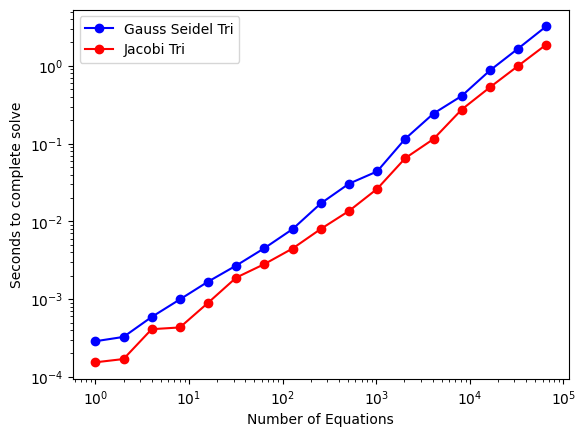

Approximate growth rate is n^ 0.952929751632232


In [51]:
import time
import matplotlib.pyplot as plt
num_tests = 17
I = 2**np.arange(num_tests)
times_j = np.zeros(num_tests)
times_jf = np.zeros(num_tests)
for test in range(num_tests):
    N = I[test]+1
    A = np.zeros((N,3))
    b = np.ones(N)

    for i in range(N):
        A[i,1] = 2.5
        if (i>0):
            A[i,0] = -1
        if (i < N-1):
            A[i,2] = -1
    print(N)
    start = time.time()
    x = JacobiTri(A,b)
    end = time.time()
    times_j[test] = end-start

    start = time.time()
    x = Gauss_Seidel_Tri(A,b)
    end = time.time()
    times_jf[test] = end-start


plt.loglog(I,times_j,'bo-',label='Gauss Seidel Tri')
plt.loglog(I,times_jf,'ro-',label='Jacobi Tri')
plt.xlabel("Number of Equations")
plt.ylabel("Seconds to complete solve")
plt.legend()
plt.show()
print("Approximate growth rate is n^",
      (np.log(times_j[test])-np.log(times_j[test-1]))/
      (np.log(I[test])-np.log(I[test-1])))

As far as I can tell, they appear to be about the same, both linear. Jacobi is faster, but only slightly